In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

tips = sns.load_dataset("tips")

display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

print("Dataset Shape:", tips.shape)
print("\nColumn Names:")
print("\nFirst Five Rows:")
display(tips.head())

Date: 2026-07-24

Student ID: DAMHAR2570

Dataset Shape: (244, 7)

Column Names:

First Five Rows:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Tip percentages
tip_percentages = [0.12, 0.18, 0.22, 0.28]

# Total bill amoints $20 - $120 in $20 increments
total_bills = np.arange(20, 121, 20)

print("Tip Percentages:", tip_percentages)
print("Total-Bill Amounts:", total_bills)

Date: 2026-07-24

Student ID: DAMHAR2570

Tip Percentages: [0.12, 0.18, 0.22, 0.28]
Total-Bill Amounts: [ 20  40  60  80 100 120]


In [3]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Scenario Analysis
results = []

for pct in tip_percentages:
    for bill in total_bills:
        total_tip = bill * pct
        results.append({
            "Tip_Percentage": pct,
            "Total_Bill": bill,
            "Total_Tip": total_tip
        })

results_df = pd.DataFrame(results)

display(results_df.head())

Date: 2026-07-24

Student ID: DAMHAR2570

,Tip_Percentage,Total_Bill,Total_Tip
0,0.12,20,2.4
1,0.12,40,4.8
2,0.12,60,7.2
3,0.12,80,9.6
4,0.12,100,12.0


Date: 2026-07-24

Student ID: DAMHAR2570

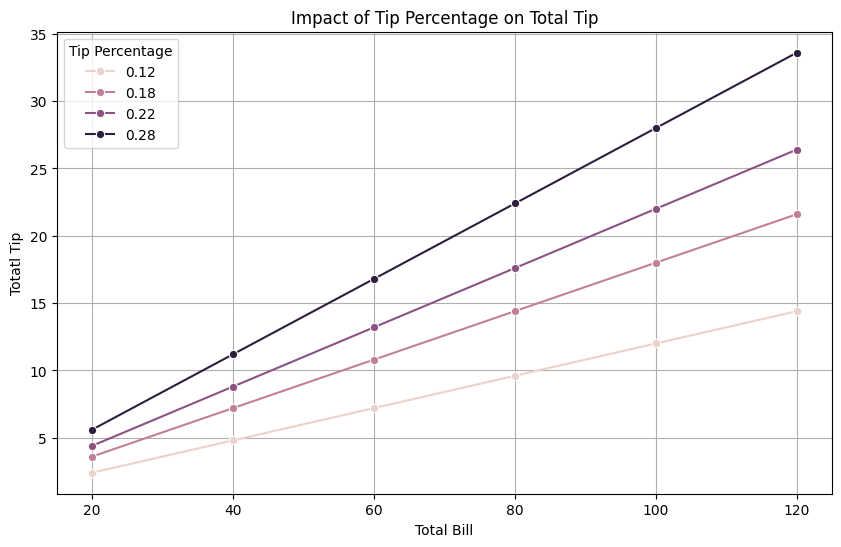

In [4]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
#Visualize Impact
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=results_df,
    x="Total_Bill",
    y="Total_Tip",
    hue="Tip_Percentage",
    marker="o"
)

plt.title("Impact of Tip Percentage on Total Tip")
plt.xlabel("Total Bill")
plt.ylabel("Totatl Tip")
plt.grid(True)
plt.legend(title="Tip Percentage")
plt.show()

Date: 2026-07-24

Student ID: DAMHAR2570

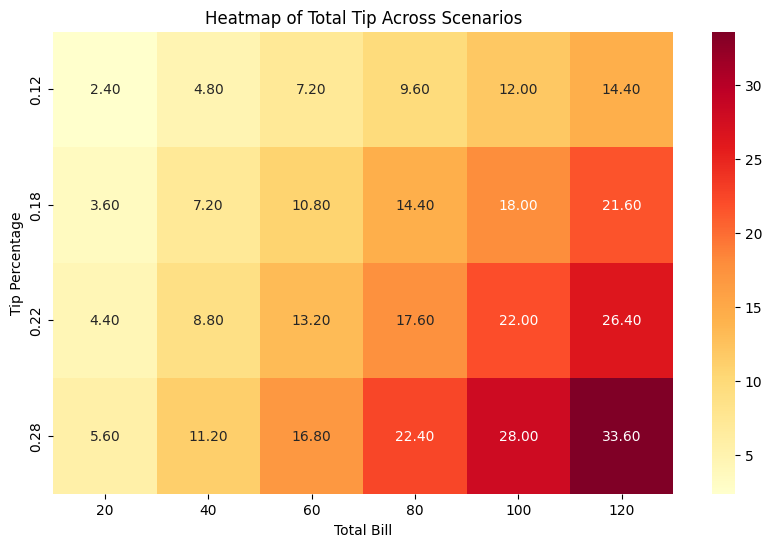

In [5]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# Visualize Combine Scenario Heatmap
pivot_df = results_df.pivot(
    index="Tip_Percentage",
    columns="Total_Bill",
    values="Total_Tip"
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)

plt.title("Heatmap of Total Tip Across Scenarios")
plt.xlabel("Total Bill")
plt.ylabel("Tip Percentage")
plt.show()

Date: 2026-07-24

Student ID: DAMHAR2570

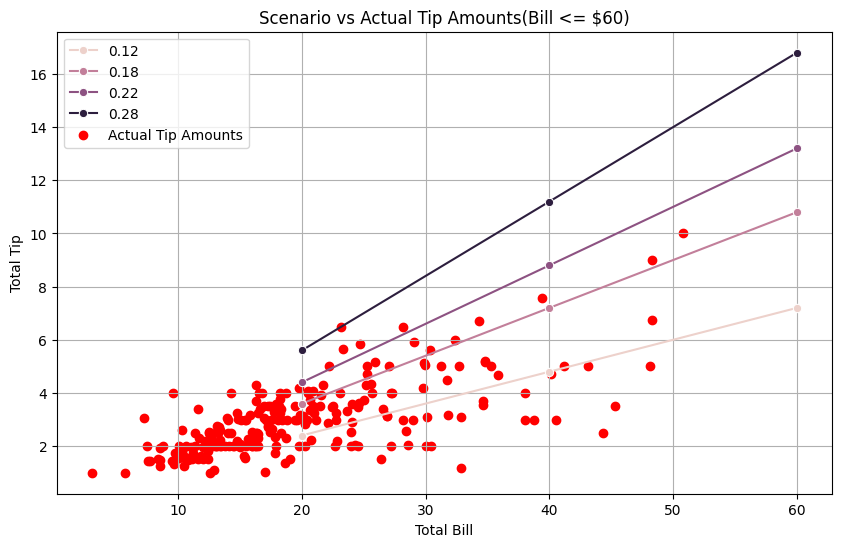

In [6]:
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
# COmpare Scenario Results with Actual Data
tips["actual_tip_pct"] = tips["tip"] / tips["total_bill"]
actual_avg = tips.groupby("total_bill")["actual_tip_pct"].mean().reset_index()
actual_filtered = actual_avg[actual_avg["total_bill"]<= 60]

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=results_df[results_df["Total_Bill"] <= 60],
    x="Total_Bill",
    y="Total_Tip",
    hue="Tip_Percentage",
    marker="o"
)

plt.scatter(
    actual_filtered["total_bill"],
    actual_filtered["actual_tip_pct"] * actual_filtered["total_bill"],
    color="red",
    label="Actual Tip Amounts"
)

plt.title("Scenario vs Actual Tip Amounts(Bill <= $60)")
plt.xlabel("Total Bill")
plt.ylabel("Total Tip")
plt.grid(True)
plt.legend()
plt.show()

What differences were observed among the tip-percentage scenarios?
Higher tip percentages lead to larger total tip amounts and the differences grew as total bills increased

How did changing the total bill amount and tip percentage affect the total tip outcome?
The total tip increased linearly with both variables. Larger bills amplified the effect of higher tip percentages.

How closely did the selected scenarios compare with the actual tip data?
Actual tips varied more than the fixed percentage scenarios, showing that real world tipping behavior is inconsistent.

How could scenario analysis support decision making in another real world situation?
Scenario analysis helps forecast outcomes under different assumptions which are useful for budgeting, pring and staffing plannning